In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

diabetes_data = pd.read_csv("./diabetes.csv")
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [42]:
diabetes_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [43]:
def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)

    print("Confusion matrix:", confusion)
    print(accuracy, precision, recall, f1, roc_auc)

In [44]:
def precision_recall_curve_plot(y_test=None, pred_prob_c1=None):
    precisions, recalls, thresholds = precision_recall_curve(y_test, pred_prob_c1)
    plt.figure(figsize=(8, 6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle="--", label="precision")
    plt.plot(thresholds, recalls[0:threshold_boundary], linestyle="--", label="recall")

    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))

    plt.xlabel("THRESHOLDS VALUE")
    plt.ylabel("PRECISION, RECALL VALUE")
    plt.legend()
    plt.grid()
    plt.show()


In [45]:
X = diabetes_data.iloc[:, :-1]
y = diabetes_data.iloc[:, -1]

# 외우기 (빅분기실기)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# stratify = y <- 불균형 데이터에서 결괏값 보정을 위해 사용(균등하게 데이터를 뽑아옴)

lr_clf = LogisticRegression(solver="liblinear")
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:, 1]
# 여기까지

get_clf_eval(y_test, pred, pred_proba)


Confusion matrix: [[85 15]
 [27 27]]
0.7272727272727273 0.6428571428571429 0.5 0.5625 0.8287037037037037


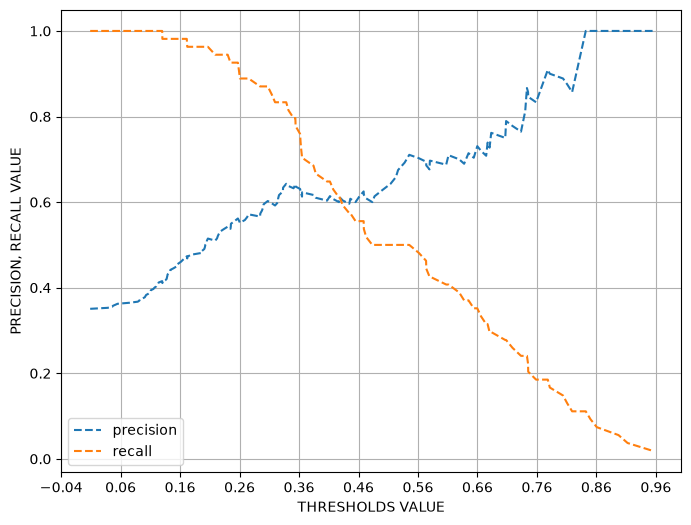

In [46]:
pred_proba_c1 = lr_clf.predict_proba(X_test)[:, 1]

precision_recall_curve_plot(y_test, pred_proba_c1)

In [47]:
diabetes_data.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


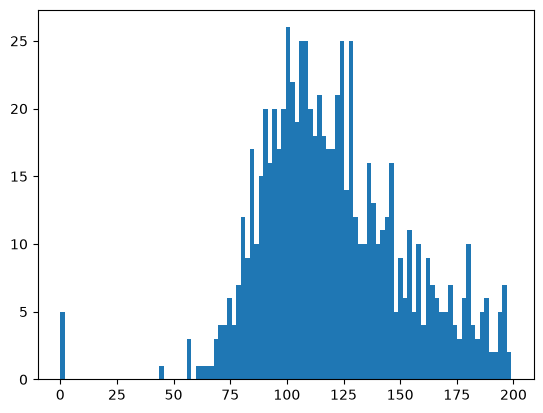

In [48]:
plt.hist(diabetes_data["Glucose"], bins=100)
plt.show()

In [49]:
zero_features = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

total_count = diabetes_data["Glucose"].count()

for feature in zero_features:
    zero_count = diabetes_data[diabetes_data[feature] == 0][feature].count()
    print(feature)
    print(zero_count)
    print((zero_count/total_count) * 100)

Glucose
5
0.6510416666666667
BloodPressure
35
4.557291666666666
SkinThickness
227
29.557291666666668
Insulin
374
48.69791666666667
BMI
11
1.4322916666666665


In [50]:
# 결측치 처리
mean_zero_features = diabetes_data[zero_features].mean()
diabetes_data[zero_features] = diabetes_data[zero_features].replace(0, mean_zero_features)

In [51]:
X = diabetes_data.iloc[:, :-1]
y = diabetes_data.iloc[:, -1]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

lr_clf = LogisticRegression(solver="liblinear")
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, pred, pred_proba)

Confusion matrix: [[82 18]
 [27 27]]
0.7077922077922078 0.6 0.5 0.5454545454545454 0.8144444444444444


In [52]:
from sklearn.preprocessing import Binarizer

def get_eval_by_threshold(y_test, pred_prob_c1, thresholds):
    for custom_threshold in thresholds:
        binarizer = Binarizer(threshold = custom_threshold).fit(pred_prob_c1)
        custom_predict = binarizer.transform(pred_prob_c1)
        print("임계값:", custom_threshold)
        get_clf_eval(y_test, custom_predict, pred_proba_c1)

In [53]:
thresholds = [0.3, 0.33, 0.36, 0.39, 0.42, 0.45, 0.48, 0.50]
pred_proba = lr_clf.predict_proba(X_test)
get_eval_by_threshold(y_test, pred_proba[:,1].reshape(-1, 1), thresholds)

임계값: 0.3
Confusion matrix: [[72 28]
 [11 43]]
0.7467532467532467 0.6056338028169014 0.7962962962962963 0.688 0.8287037037037037
임계값: 0.33
Confusion matrix: [[73 27]
 [15 39]]
0.7272727272727273 0.5909090909090909 0.7222222222222222 0.65 0.8287037037037037
임계값: 0.36
Confusion matrix: [[76 24]
 [17 37]]
0.7337662337662337 0.6065573770491803 0.6851851851851852 0.6434782608695652 0.8287037037037037
임계값: 0.39
Confusion matrix: [[78 22]
 [19 35]]
0.7337662337662337 0.6140350877192983 0.6481481481481481 0.6306306306306306 0.8287037037037037
임계값: 0.42
Confusion matrix: [[78 22]
 [23 31]]
0.7077922077922078 0.5849056603773585 0.5740740740740741 0.5794392523364486 0.8287037037037037
임계값: 0.45
Confusion matrix: [[79 21]
 [24 30]]
0.7077922077922078 0.5882352941176471 0.5555555555555556 0.5714285714285714 0.8287037037037037
임계값: 0.48
Confusion matrix: [[80 20]
 [25 29]]
0.7077922077922078 0.5918367346938775 0.5370370370370371 0.5631067961165048 0.8287037037037037
임계값: 0.5
Confusion matrix: [[82 18